<a href="https://colab.research.google.com/github/qbgbduenas-ship-it/CPE-018-CPE31S2/blob/main/DUENAS__Activity_9_ORB_Feature_Detection_and_Feature_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
2nd Semester | AY 2025-2026
<hr> | <hr>
<u>**Hands-on Activity 8.1** | **TITLE**  ORB Feature Detection and Feature Matching

**Name** | Duenas, Beatrice Gillianne B.
**Section** | CPE31S2
**Date Performed**: | 24/03/2026
**Date Submitted**: | 24/03/2026
**Instructor**: |Engr. Rizette Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

image1 = cv2.imread('/content/playstation-47410.jpg', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/s-l1600.jpg', cv2.IMREAD_GRAYSCALE)

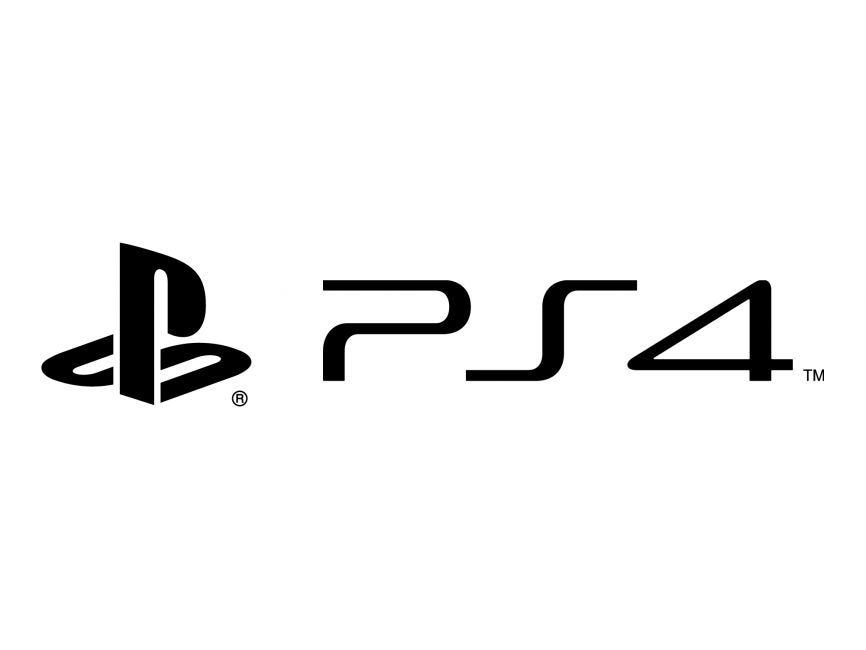

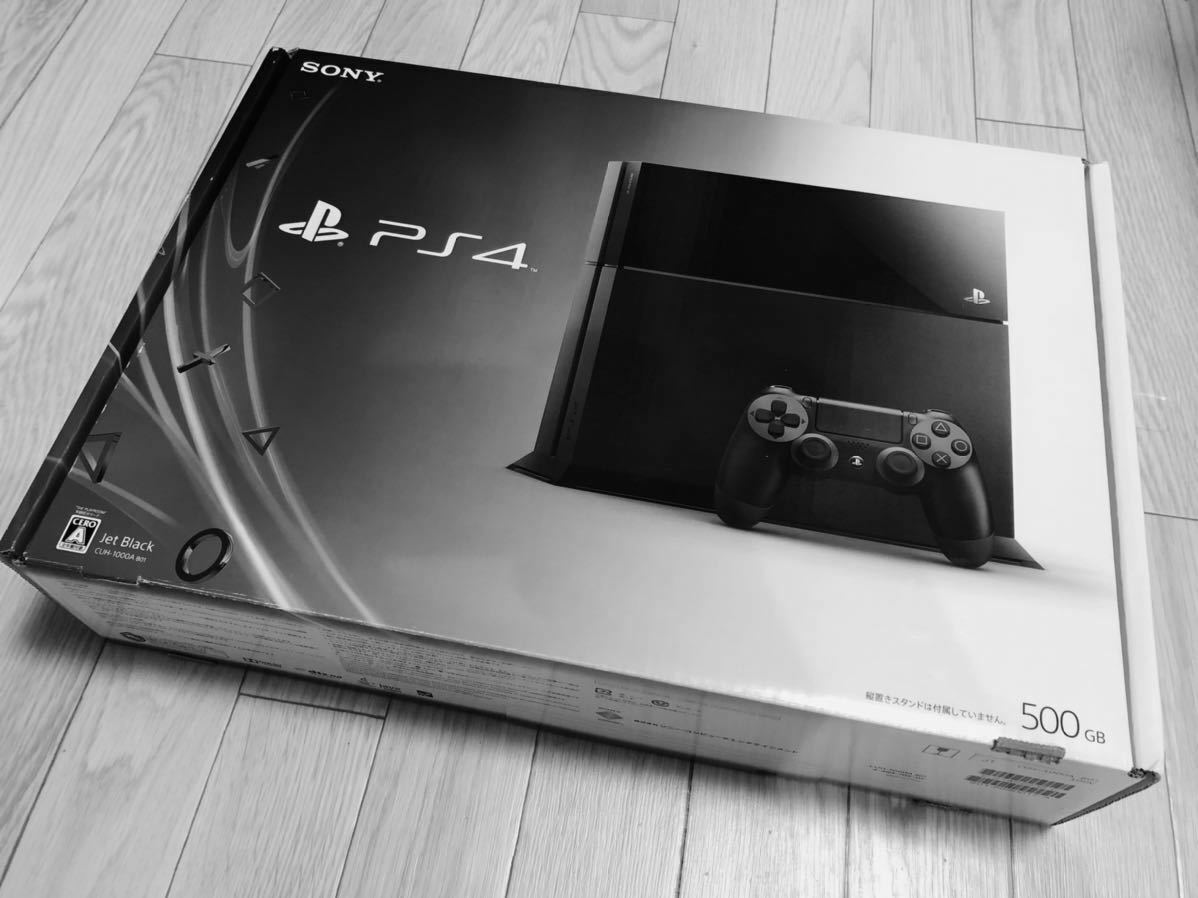

In [ ]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of detector and descriptor and why they're used here.**
- The detector identifies keypoints distinctive locations in an image—while the descriptor encodes their appearance for matching. They are used here to find and compare logo features across different product images efficiently.


In [ ]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [ ]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

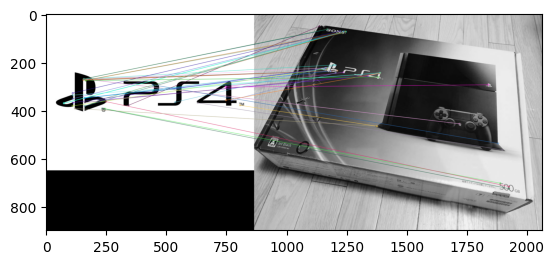

(<matplotlib.image.AxesImage at 0x7fe285cab940>, None)

In [ ]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
- Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?
-ORB detects keypoints, computes descriptors, and matches them using Hamming distance, but the results are incorrect because matching is done before computing descriptors. Fix the order and use KNN with ratio test to improve accuracy.


## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**

Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

In [9]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive

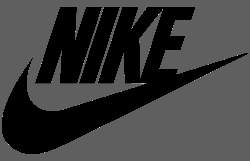

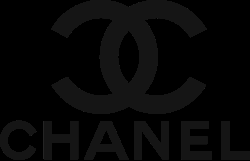

In [10]:
#1.Find 2 images of brand logos on the internet

logo1_img = cv2.imread('/content/drive/MyDrive/EMTECH1/HOA/Nike_logo.png', cv2.IMREAD_GRAYSCALE)
logo2_img = cv2.imread('/content/drive/MyDrive/EMTECH1/HOA/chanel_logo.png', cv2.IMREAD_GRAYSCALE)

logo1_resized = cv2.resize(logo1_img, (logo2_img.shape[1], logo2_img.shape[0]))

cv2_imshow(logo1_resized)
cv2_imshow(logo2_img)

In [11]:
#2. Find 5 product images containing one logo each.
product_chanel = ['/content/drive/MyDrive/EMTECH1/HOA/CHANEL/chanel1.jpg', '/content/drive/MyDrive/EMTECH1/HOA/CHANEL/chanel2.jpg',
                  '/content/drive/MyDrive/EMTECH1/HOA/CHANEL/chanel3.jfif', '/content/drive/MyDrive/EMTECH1/HOA/CHANEL/chanel4.jfif',
                  '/content/drive/MyDrive/EMTECH1/HOA/CHANEL/chanel5.jfif']
product_nike = ['/content/drive/MyDrive/EMTECH1/HOA/NIKE/nike1.jfif', '/content/drive/MyDrive/EMTECH1/HOA/NIKE/nike2.jfif',
                  '/content/drive/MyDrive/EMTECH1/HOA/NIKE/nike3.webp', '/content/drive/MyDrive/EMTECH1/HOA/NIKE/nike4.jpg',
                  '/content/drive/MyDrive/EMTECH1/HOA/NIKE/nike5.jfif']
product_images = product_chanel + product_nike

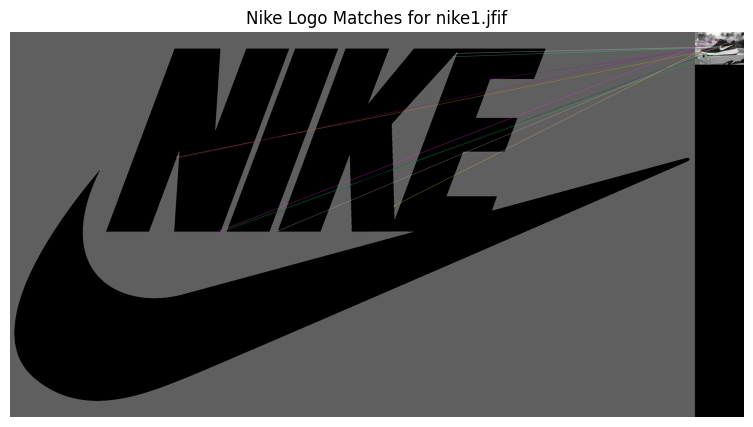

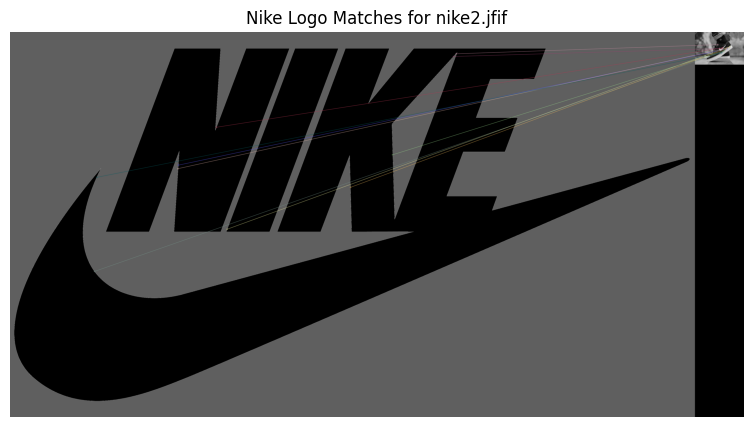

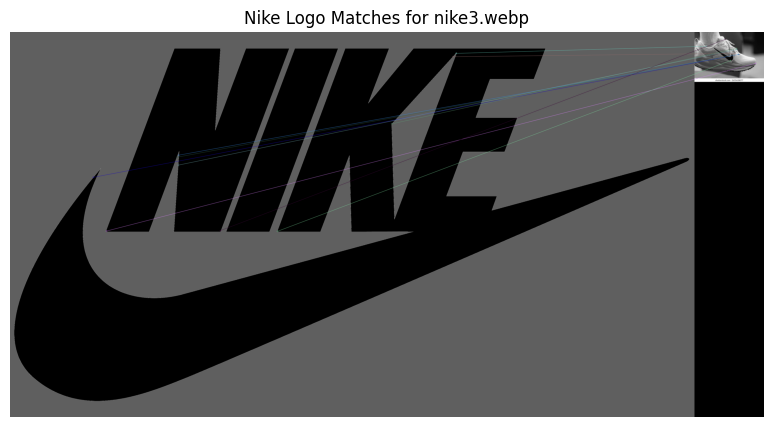

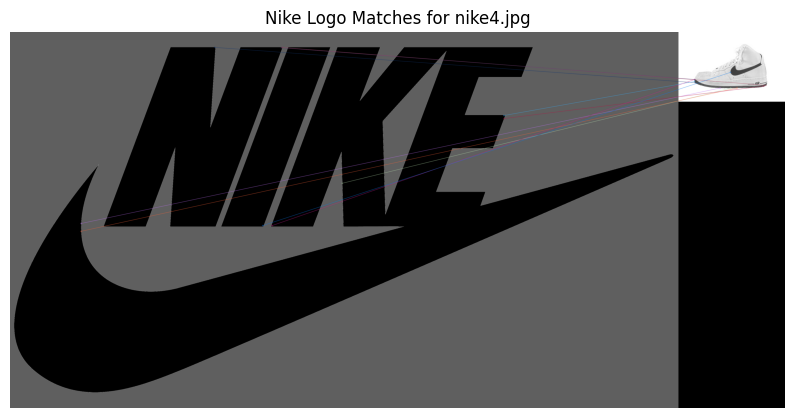

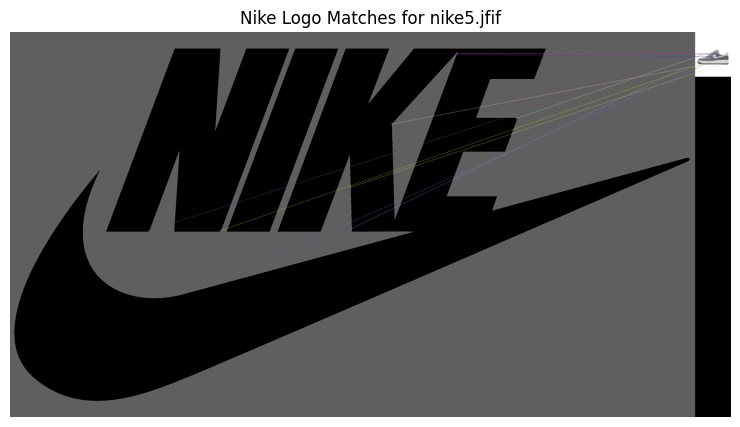

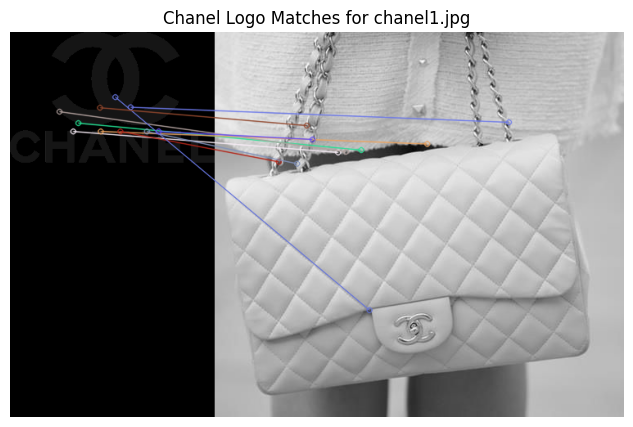

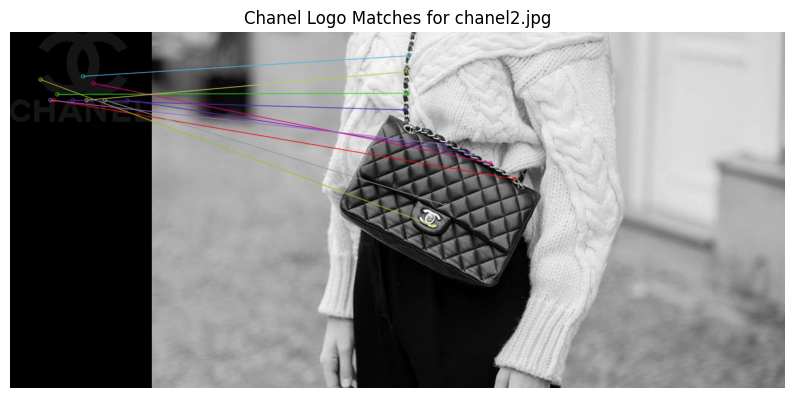

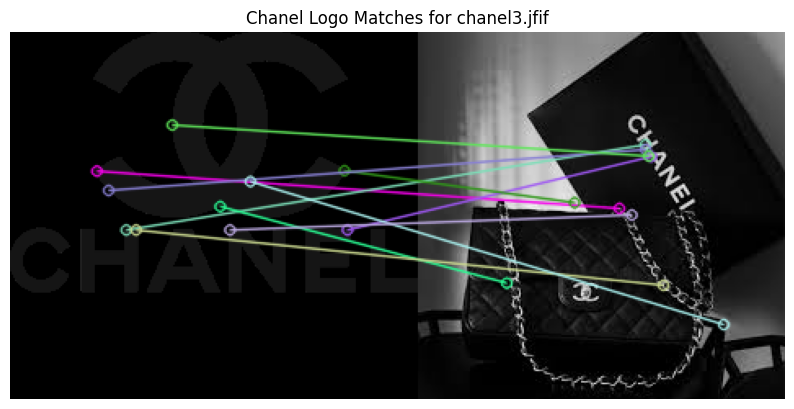

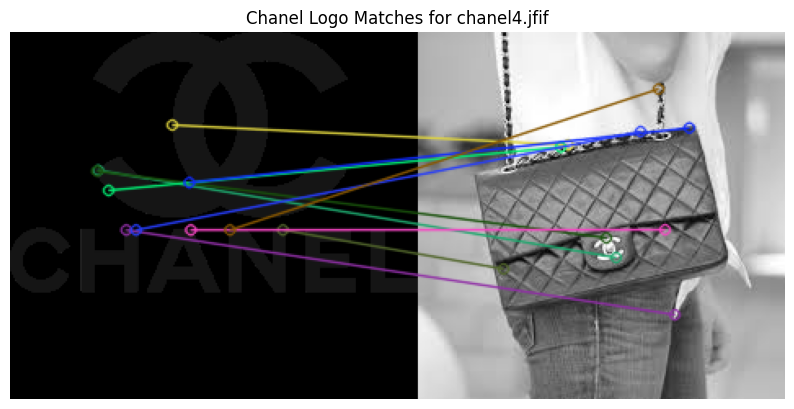

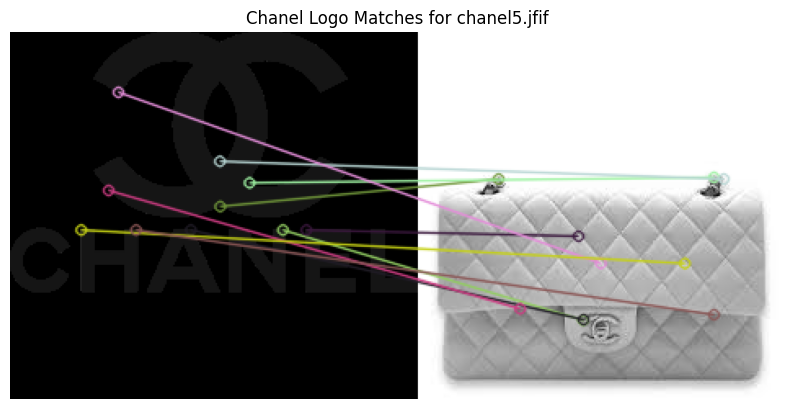

In [12]:
#3. Test the ORB algorithm to detect and match the features on the images. Document the testing.

orb = cv2.ORB_create(nfeatures=1000)

def process_images(logo_img, product_images, logo_name):
    kp1, des1 = orb.detectAndCompute(logo_img, None)

    for product_img_path in product_images:
        product_img = cv2.imread(product_img_path, cv2.IMREAD_GRAYSCALE)

        if product_img is None:
            print(f"Image not found: {product_img_path}")
            continue

        kp2, des2 = orb.detectAndCompute(product_img, None)

        if des2 is None:
            print(f"No features detected in {product_img_path}")
            continue

        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)

        match_img = cv2.drawMatches(logo_img, kp1, product_img, kp2, matches[:10], None, flags=2)

        plt.figure(figsize=(10, 5))
        plt.imshow(match_img, cmap='gray')
        plt.title(f'{logo_name} Matches for {product_img_path.split("/")[-1]}')
        plt.axis('off')
        plt.show()

process_images(logo1_img, product_nike, 'Nike Logo')
process_images(logo2_img, product_chanel, 'Chanel Logo')

4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?

- Using the discussions and lessons, I was able to perform this activity. When testing the ORB algorithm on the logo and product images, it was generally able to detect the important features of each logo, such as the edges, curves, and distinctive shapes of the Nike swoosh and the Chanel logo. The keypoints and descriptors matched well on product images that actually contained the logos, showing lines connecting corresponding features clearly. As seen above the, it was able to determine what features has the same with the provided images.


5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?
- The ORB algorithm worked well on clear, high-contrast logos but struggled with cluttered backgrounds or rotated images. To improve results, I would preprocess images to enhance contrast, use multi-scale ORB to handle size variations, and apply image masking to focus only on the logo area.


## 5. Summary, Conclusions and Lessons Learned

SUMMARY

- This hands-on activity, is all about ORB feature detection and feature matching. This aids in detecting and matching features (like logo) which allows the image to detect some symbols by recognizing the object, image stitching, and as well as the logo detection.ORB is especially valuable since it is fast, efficient, and robust to rotation, meaning it can reliably identify the same object even if the image is rotated or slightly transformed. This makes it practical for real-time applications and large image datasets. It builds on the FAST keypoint detector and the BRIEF descriptor, adding orientation and rotational invariance to improve accuracy.

CONCLUSIONS
- ORB is important because it allows fast and accurate detection and matching of key features, it helps in detecting the images, and even when images are rotated or transformed. This makes it essential for applications like object recognition, logo detection, and real-time computer vision tasks.


LESSONS LEARNED
- As a student, it helped me enhance my understanding and widen my knowledge in terms of detection programming. I have learned that ORB combines FAST keypoint detection with BRIEF descriptors, making it both fast and accurate. Matching works best when the reference logo and product image are similar in size, and visualizing the matches helps understand how well the algorithm identifies key features.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*